# Single Game Analysis

This notebook demonstrates running a single game with PyTorch AI players and analyzing its output.

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

from eucher.ai_players.pytorch_player import PyTorchStrategicPlayer
from eucher.cards import Card, Suit
from eucher.game import Game
from eucher.players import Player
from eucher.players.base import PlayerProfile
import json
from datetime import datetime

print("Imports successful")


Imports successful


## Create PyTorch Player Profile Wrapper

In [2]:
class PyTorchPlayerProfile(PlayerProfile):
    """Wrapper profile that uses PyTorchStrategicPlayer with risk factors."""

    def __init__(self, model_path=None, device=None, trump_selection_risk=0.5, gameplay_risk=0.5, player_name="PyTorch AI"):
        super().__init__()
        self.player_name = player_name
        self.pytorch_player = PyTorchStrategicPlayer(
            model_path=model_path, device=device,
            trump_selection_risk=trump_selection_risk, gameplay_risk=gameplay_risk
        )

    def decide_order_up(self, player, turned_card, dealer_id, trump_suit=None):
        return self.pytorch_player.decide_order_up(player, turned_card, dealer_id, trump_suit)

    def decide_call_trump(self, player, turned_card, trump_suit=None, must_choose=False):
        return self.pytorch_player.decide_call_trump(player, turned_card, trump_suit, must_choose)

    def choose_card_to_discard(self, player, turned_card=None, ordered_up_by=None):
        return self.pytorch_player.choose_card_to_discard(player, turned_card, ordered_up_by)

    def play_card(self, player, led_suit=None, trump_suit=None, trick_cards=None, trick_player_ids=None):
        return self.pytorch_player.play_card(player, led_suit, trump_suit, trick_cards, trick_player_ids)


    
    def decide_going_alone(self, player, trump_suit):
        """Decide whether to go alone. Default: False."""
        return False
    
    def decide_trade_in(self, player, eligible_cards):
        """Decide whether to trade in. Default: False."""
        return False

print("PyTorchPlayerProfile class defined")

PyTorchPlayerProfile class defined


## Play a Single Game

In [3]:
# Define risk factors for 4 players
risk_factors = [
    (0.2, 0.2),  # Player 1: Conservative
    (0.5, 0.5),  # Player 2: Balanced
    (0.7, 0.7),  # Player 3: Aggressive
    (0.9, 0.9),  # Player 4: Very Aggressive
]

# Create profiles
profiles = []
for i, (trump_risk, gameplay_risk) in enumerate(risk_factors):
    profile = PyTorchPlayerProfile(
        trump_selection_risk=trump_risk,
        gameplay_risk=gameplay_risk,
        player_name=f"PyTorch AI {i+1}",
    )
    profiles.append(profile)

# Create game
player_config = [
    ("PyTorch AI 1", "heuristic"),
    ("PyTorch AI 2", "heuristic"),
    ("PyTorch AI 3", "heuristic"),
    ("PyTorch AI 4", "heuristic"),
]
game = Game(player_config)

# Replace profiles
for i, profile in enumerate(profiles):
    game.players[i].profile = profile

print("Game created with 4 PyTorch AI players")

Game created with 4 PyTorch AI players


## Run the Game

In [4]:
# Track game data
game_data = {
    "hands": [],
    "turned_cards": [],
    "trump_suits": [],
    "scores_by_hand": [],
}

hands_played = 0

print("Starting game...")
print("=" * 60)

while True:
    hands_played += 1
    
    # Get turned card from first hand
    if hands_played == 1:
        first_turned_card = game.turned_card if hasattr(game, 'turned_card') else None
        if first_turned_card:
            game_data["turned_cards"].append(str(first_turned_card))
    
    # Play hand
    continue_game = game.play_hand()
    
    # Record hand data
    hand_data = {
        "hand_number": hands_played,
        "scores": tuple(game.scores),
        "trump_suit": str(game.trump_suit) if game.trump_suit else None,
    }
    game_data["hands"].append(hand_data)
    game_data["scores_by_hand"].append(tuple(game.scores))
    
    if game.trump_suit:
        game_data["trump_suits"].append(str(game.trump_suit))
    
    print(f"Hand {hands_played}: Team 0 = {game.scores[0]}, Team 1 = {game.scores[1]}")
    
    # Check for winner
    winner = game.get_winner()
    if winner is not None:
        print(f"\nGame Over! Team {winner} wins!")
        game_data["winner"] = winner
        game_data["final_scores"] = tuple(game.scores)
        break
    
    if not continue_game:
        print("\nGame ended")
        break

game_data["total_hands"] = hands_played
game_data["risk_factors"] = risk_factors

print("=" * 60)
print(f"Total hands played: {hands_played}")
print(f"Final scores: Team 0 = {game.scores[0]}, Team 1 = {game.scores[1]}")

Starting game...


Hand 1: Team 0 = 2, Team 1 = 0


Hand 2: Team 0 = 2, Team 1 = 2


Hand 3: Team 0 = 3, Team 1 = 2
Hand 4: Team 0 = 3, Team 1 = 4
Hand 5: Team 0 = 3, Team 1 = 5


Hand 6: Team 0 = 5, Team 1 = 5
Hand 7: Team 0 = 5, Team 1 = 7


Hand 8: Team 0 = 6, Team 1 = 7


Hand 9: Team 0 = 6, Team 1 = 8
Hand 10: Team 0 = 6, Team 1 = 10

Game Over! Team 1 wins!
Total hands played: 10
Final scores: Team 0 = 6, Team 1 = 10


## Display Game Results

In [5]:
import pandas as pd

# Create DataFrame for hands
hands_df = pd.DataFrame(game_data["hands"])
print("Hand-by-Hand Progression:")
print(hands_df.to_string(index=False))

print("\n" + "=" * 60)
print("Game Summary:")
if 'winner' in game_data:
    print(f"Winner: Team {game_data['winner']}")
print(f"Final Scores: Team 0 = {game_data['final_scores'][0]}, Team 1 = {game_data['final_scores'][1]}")
print(f"Total Hands: {game_data['total_hands']}")
print(f"\nRisk Factors:")
for i, (trump, gameplay) in enumerate(game_data['risk_factors']):
    print(f"  Player {i+1}: Trump={trump:.2f}, Gameplay={gameplay:.2f}")

if game_data["turned_cards"]:
    print(f"\nFirst Turned Card: {game_data['turned_cards'][0]}")

if game_data["trump_suits"]:
    from collections import Counter
    trump_counts = Counter(game_data["trump_suits"])
    print(f"\nTrump Suits Called:")
    for suit, count in trump_counts.items():
        print(f"  {suit}: {count} times")

Hand-by-Hand Progression:
 hand_number  scores    trump_suit
           1  (2, 0)   Suit.SPADES
           2  (2, 2)   Suit.SPADES
           3  (3, 2)    Suit.CLUBS
           4  (3, 4)    Suit.CLUBS
           5  (3, 5)   Suit.SPADES
           6  (5, 5)    Suit.CLUBS
           7  (5, 7)   Suit.HEARTS
           8  (6, 7)    Suit.CLUBS
           9  (6, 8)   Suit.SPADES
          10 (6, 10) Suit.DIAMONDS

Game Summary:
Winner: Team 1
Final Scores: Team 0 = 6, Team 1 = 10
Total Hands: 10

Risk Factors:
  Player 1: Trump=0.20, Gameplay=0.20
  Player 2: Trump=0.50, Gameplay=0.50
  Player 3: Trump=0.70, Gameplay=0.70
  Player 4: Trump=0.90, Gameplay=0.90

Trump Suits Called:
  Suit.SPADES: 4 times
  Suit.CLUBS: 4 times
  Suit.HEARTS: 1 times
  Suit.DIAMONDS: 1 times


## Visualize Game Progression

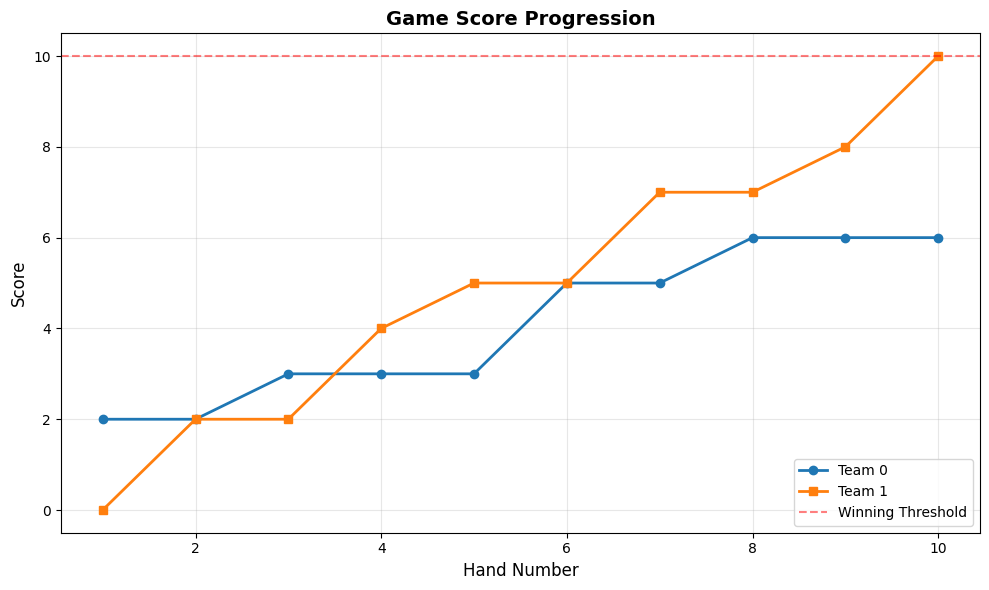

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

hand_numbers = [h["hand_number"] for h in game_data["hands"]]
team0_scores = [h["scores"][0] for h in game_data["hands"]]
team1_scores = [h["scores"][1] for h in game_data["hands"]]

ax.plot(hand_numbers, team0_scores, marker='o', label='Team 0', linewidth=2)
ax.plot(hand_numbers, team1_scores, marker='s', label='Team 1', linewidth=2)
ax.axhline(y=10, color='r', linestyle='--', alpha=0.5, label='Winning Threshold')

ax.set_xlabel('Hand Number', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Game Score Progression', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()